In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("../data/network_incidents.csv")

df.head()

,Timestamp,Device,Location,Incident_Type,Severity,CPU_Usage,Memory_Usage,Packet_Loss_Percentage,Resource_Stress,Network_Stress
0,2026-05-11 11:31:28.074450,R1-Core,Mumbai,BGP Neighbor Down,Critical,90,48,13.15,138,131.5
1,2026-05-11 11:36:28.074450,R1-Core,Delhi,BGP Neighbor Down,Major,90,70,13.32,160,133.2
2,2026-05-11 11:41:28.074450,R1-Core,Mumbai,BGP Neighbor Down,Major,72,82,7.76,154,77.6
3,2026-05-11 11:46:28.074450,R2-Branch,Pune,Route Flapping,Critical,94,94,13.66,188,136.6
4,2026-05-11 11:51:28.074450,SW2-Distribution,Delhi,Memory Utilization High,Warning,100,78,1.62,178,16.2


In [3]:
df["Critical_Incident"] = df["Severity"].apply(
    lambda x: 1 if x == "Critical" else 0
)

df.head()

,Timestamp,Device,Location,Incident_Type,Severity,CPU_Usage,Memory_Usage,Packet_Loss_Percentage,Resource_Stress,Network_Stress,Critical_Incident
0,2026-05-11 11:31:28.074450,R1-Core,Mumbai,BGP Neighbor Down,Critical,90,48,13.15,138,131.5,1
1,2026-05-11 11:36:28.074450,R1-Core,Delhi,BGP Neighbor Down,Major,90,70,13.32,160,133.2,0
2,2026-05-11 11:41:28.074450,R1-Core,Mumbai,BGP Neighbor Down,Major,72,82,7.76,154,77.6,0
3,2026-05-11 11:46:28.074450,R2-Branch,Pune,Route Flapping,Critical,94,94,13.66,188,136.6,1
4,2026-05-11 11:51:28.074450,SW2-Distribution,Delhi,Memory Utilization High,Warning,100,78,1.62,178,16.2,0


In [4]:
encoder = LabelEncoder()

df["Device"] = encoder.fit_transform(df["Device"])
df["Location"] = encoder.fit_transform(df["Location"])
df["Incident_Type"] = encoder.fit_transform(df["Incident_Type"])

In [5]:
X = df[[
    "Device",
    "Location",
    "Incident_Type",
    "CPU_Usage",
    "Memory_Usage",
    "Packet_Loss_Percentage",
    "Resource_Stress",
    "Network_Stress"
]]

y = df["Critical_Incident"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Accuracy: 0.93

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.93      0.96        88
           1       0.65      0.92      0.76        12

    accuracy                           0.93       100
   macro avg       0.82      0.92      0.86       100
weighted avg       0.95      0.93      0.94       100



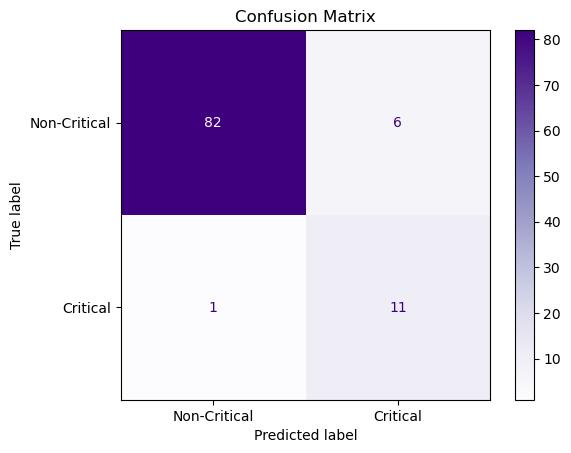

Model saved successfully.


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Critical", "Critical"]
)

disp.plot(cmap="Purples")

plt.title("Confusion Matrix")

plt.show()

# Save model
joblib.dump(model, "../models/decision_tree_model.pkl")

print("Model saved successfully.")